<a href="https://colab.research.google.com/github/Pensive1881/DSR44_2025/blob/main/scratchpad_mnist_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Obtain the data

In [ ]:
import torch
import torchvision

In [ ]:
from torchvision.datasets import MNIST

data_path = '../data/'
mnist = MNIST(data_path, download=True)

In [ ]:
mnist[0]

(<PIL.Image.Image image mode=L size=28x28>, 5)

In [ ]:
mnist[0][0]

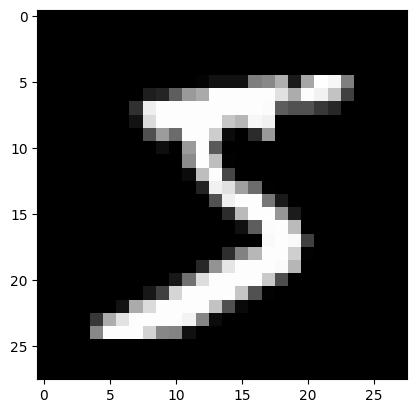

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(mnist[0][0], cmap='gray');

## Exploring Convolutions

In [ ]:
pil_image = mnist[0][0]
pil_image

In [ ]:
import numpy as np
np.exp(np.array(pil_image))

/tmp/ipython-input-1585422661.py:2: RuntimeWarning: overflow encountered in exp
  np.exp(np.array(pil_image))


array([[1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00,
        1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00,
        1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00,
        1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00,
        1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00],
       [1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00,
        1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00,
        1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00,
        1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00,
        1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00],
       [1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00,
        1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00,
        1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00,
        1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00, 1.000e+00,
      

In [ ]:
# numerical underflow example
np.float16(0.001) ** 16

np.float16(0.0)

In [ ]:
# skip connection with addition
0.001 + np.float16(0.001) ** 16

np.float16(0.001)

In [ ]:
np.float32(0.001) ** 16

np.float32(0.0)

In [ ]:
np.float64(0.001) ** 16

np.float64(1.0000000000000003e-48)

In [ ]:
# turn the pil_image into a torch tensor
import torchvision.transforms.v2 as transforms

scaling_transformation = transforms.Compose([
    transforms.ToImage(),
    transforms.ToDtype(torch.float32, scale=True)
])

scaled_tensor = scaling_transformation(pil_image)
scaled_tensor

Image([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000],
        [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000

In [ ]:
scaled_tensor.shape

torch.Size([1, 28, 28])

In [ ]:
scaled_tensor.squeeze().shape

torch.Size([28, 28])

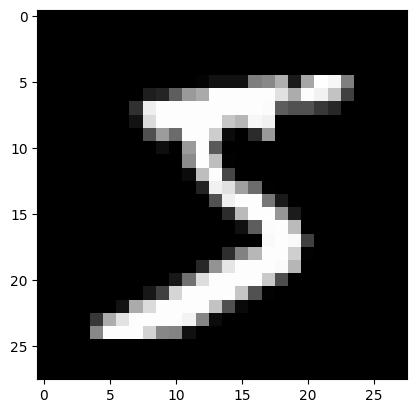

In [ ]:
plt.imshow(scaled_tensor.squeeze().numpy(), cmap='gray');

In [ ]:
import torch.nn as nn
conv2d_demo_1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=3, padding=1)

In [ ]:
conv2d_demo_1(scaled_tensor).shape

torch.Size([6, 28, 28])

In [ ]:
output_conv2d_demo_1 = conv2d_demo_1(scaled_tensor)
output_conv2d_demo_1.shape

torch.Size([6, 28, 28])

In [ ]:
next(iter(conv2d_demo_1.parameters()))

Parameter containing:
tensor([[[[-0.1571, -0.0116, -0.0887],
          [-0.0867,  0.0313,  0.2637],
          [-0.0271,  0.3249, -0.1791]]],


        [[[ 0.1448, -0.1139,  0.2107],
          [ 0.2260,  0.3310,  0.1684],
          [-0.0542, -0.0946, -0.1916]]],


        [[[ 0.1206,  0.1660, -0.2847],
          [ 0.2060, -0.1136,  0.0803],
          [ 0.1115, -0.2010,  0.0859]]],


        [[[-0.0762,  0.2052,  0.3054],
          [-0.2599,  0.2540, -0.2574],
          [-0.0725, -0.1587,  0.0417]]],


        [[[-0.0429,  0.2923,  0.1969],
          [ 0.2954,  0.1931,  0.1811],
          [-0.2060,  0.3193,  0.1678]]],


        [[[-0.0242,  0.1059,  0.0300],
          [ 0.1036,  0.0473, -0.2976],
          [-0.2476, -0.1685,  0.2601]]]], requires_grad=True)

In [ ]:
output_conv2d_demo_1

tensor([[[-0.2842, -0.2842, -0.2842,  ..., -0.2842, -0.2842, -0.2842],
         [-0.2842, -0.2842, -0.2842,  ..., -0.2842, -0.2842, -0.2842],
         [-0.2842, -0.2842, -0.2842,  ..., -0.2842, -0.2842, -0.2842],
         ...,
         [-0.2842, -0.2842, -0.2842,  ..., -0.2842, -0.2842, -0.2842],
         [-0.2842, -0.2842, -0.2842,  ..., -0.2842, -0.2842, -0.2842],
         [-0.2842, -0.2842, -0.2842,  ..., -0.2842, -0.2842, -0.2842]],

        [[-0.1208, -0.1208, -0.1208,  ..., -0.1208, -0.1208, -0.1208],
         [-0.1208, -0.1208, -0.1208,  ..., -0.1208, -0.1208, -0.1208],
         [-0.1208, -0.1208, -0.1208,  ..., -0.1208, -0.1208, -0.1208],
         ...,
         [-0.1208, -0.1208, -0.1208,  ..., -0.1208, -0.1208, -0.1208],
         [-0.1208, -0.1208, -0.1208,  ..., -0.1208, -0.1208, -0.1208],
         [-0.1208, -0.1208, -0.1208,  ..., -0.1208, -0.1208, -0.1208]],

        [[-0.2357, -0.2357, -0.2357,  ..., -0.2357, -0.2357, -0.2357],
         [-0.2357, -0.2357, -0.2357,  ..., -0

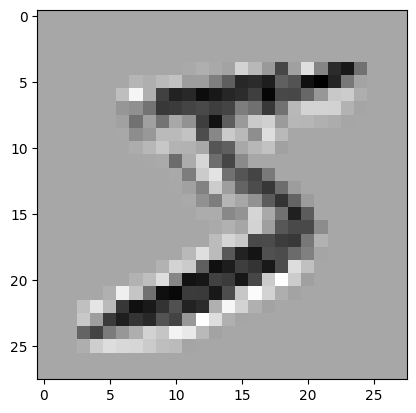

In [ ]:
# @title Visualizing output of convolutions {run:'auto'}
slider_value = 5  # @param {type: "slider", min: 0, max: 5}
plt.imshow(output_conv2d_demo_1[slider_value, :, :].detach(), cmap='gray');


## FiftyOne data visualization

In [ ]:
%%capture
!uv pip install fiftyone

In [ ]:
import fiftyone.zoo as foz

train_dataset = foz.load_zoo_dataset('mnist', split='train')
test_testset = foz.load_zoo_dataset('mnist', split='test')

Split 'train' already downloaded


INFO:fiftyone.zoo.datasets:Split 'train' already downloaded


Loading existing dataset 'mnist-train'. To reload from disk, either delete the existing dataset or provide a custom `dataset_name` to use


INFO:fiftyone.zoo.datasets:Loading existing dataset 'mnist-train'. To reload from disk, either delete the existing dataset or provide a custom `dataset_name` to use


Split 'test' already downloaded


INFO:fiftyone.zoo.datasets:Split 'test' already downloaded


Loading existing dataset 'mnist-test'. To reload from disk, either delete the existing dataset or provide a custom `dataset_name` to use


INFO:fiftyone.zoo.datasets:Loading existing dataset 'mnist-test'. To reload from disk, either delete the existing dataset or provide a custom `dataset_name` to use


In [ ]:
import fiftyone as fo

session = fo.launch_app(train_dataset, auto=False)
print(session.url)

Session launched. Run `session.show()` to open the App in a cell output.


INFO:fiftyone.core.session.session:Session launched. Run `session.show()` to open the App in a cell output.


https://5151-m-s-2lxw6u4mvhfk7-b.us-west1-1.prod.colab.dev?polling=true


## Create LeNet5 from scratch

In [ ]:
class ClassicLeNet5(nn.Module):
    """
    LeNet-5 CNN architecture for MNIST digit classification.

    Original paper: "Gradient-Based Learning Applied to Document Recognition"
    by LeCun et al. (1998)

    Architecture (maintains original design with padding):
    Input (28x28) -> Pad to (32x32) -> C1 (6@28x28) -> S2 (6@14x14) ->
    C3 (16@10x10) -> S4 (16@5x5) -> C5 (120@1x1) -> F6 (84) -> Output (10)
    """

    def __init__(self, num_classes=10):
        super(ClassicLeNet5, self).__init__()

        # Feature extraction layers
        # C1: Convolutional layer - 6 feature maps, 5x5 kernels
        # Add padding=2 to convert 28x28 input to 32x32, maintaining original design
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, stride=1, padding=2)

        # S2: Subsampling layer (average pooling) - 2x2 with stride 2
        self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)

        # C3: Convolutional layer - 16 feature maps, 5x5 kernels
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, stride=1)

        # S4: Subsampling layer (average pooling) - 2x2 with stride 2
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)

        # C5: Convolutional layer - 120 feature maps, 5x5 kernels (original design)
        # This reduces the 5x5 feature maps to 1x1
        self.conv3 = nn.Conv2d(16, 120, kernel_size=5, stride=1)

        # Classification layers
        # F6: Fully connected layer with 84 units
        self.fc1 = nn.Linear(120, 84)

        # Output layer: 10 classes for digits 0-9
        self.fc2 = nn.Linear(84, num_classes)

    def forward(self, x):
        """
        Forward pass through the network.

        Args:
            x: Input tensor of shape (batch_size, 1, 28, 28)

        Returns:
            Output logits of shape (batch_size, num_classes)
        """
        # C1: Convolution + activation (padding converts 28x28 to 32x32, then conv to 28x28)
        # Input: (batch, 1, 28, 28) -> Pad to (32, 32) -> Conv to (batch, 6, 28, 28)
        x = torch.tanh(self.conv1(x))

        # S2: Average pooling
        # Input: (batch, 6, 28, 28) -> Output: (batch, 6, 14, 14)
        x = self.pool1(x)

        # C3: Convolution + activation
        # Input: (batch, 6, 14, 14) -> Output: (batch, 16, 10, 10)
        x = torch.tanh(self.conv2(x))

        # S4: Average pooling
        # Input: (batch, 16, 10, 10) -> Output: (batch, 16, 5, 5)
        x = self.pool2(x)

        # C5: Convolution + activation (original 5x5 kernel design)
        # Input: (batch, 16, 5, 5) -> Output: (batch, 120, 1, 1)
        x = torch.tanh(self.conv3(x))

        # Flatten for fully connected layers
        # Input: (batch, 120, 1, 1) -> Output: (batch, 120)
        x = x.view(x.size(0), -1)

        # F6: Fully connected + activation
        # Input: (batch, 120) -> Output: (batch, 84)
        x = torch.tanh(self.fc1(x))

        # Output layer (no activation - raw logits)
        # Input: (batch, 84) -> Output: (batch, 10)
        x = self.fc2(x)

        return x

In [ ]:
## nn.Module is the parent class of all neural network components in PyTorch
class LeNet5(nn.Module):
    def __init__(self):
        super().__init__()
        # inside __init__() we define the attributes of the network

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=6, kernel_size=(5,5), stride=1, padding=2)
        self.pool1 = nn.AvgPool2d(kernel_size=(2,2), stride=(2, 2))

        self.conv2 = nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1)
        self.pool2 = nn.AvgPool2d(kernel_size=(2,2), stride=(2, 2))

        self.conv3 = nn.Conv2d(in_channels=16, out_channels=120, kernel_size=5, stride=1)

        self.linear1 = nn.Linear(in_features=120, out_features=84)
        self.linear2 = nn.Linear(in_features=84, out_features=10)

    def forward(self, x):
        """
          Forward pass through the network.

          Args:
              x: Input tensor of shape (batch_size, 1, 28, 28)

          Returns:
              Output logits of shape (batch_size, num_classes)
          """
        # C1: Convolution + activation (padding converts 28x28 to 32x32, then conv to 28x28)
        # Input: (batch, 1, 28, 28) -> Pad to (32, 32) -> Conv to (batch, 6, 28, 28)
        x = torch.relu(self.conv1(x))

        # S2: Average pooling
        # Input: (batch, 6, 28, 28) -> Output: (batch, 6, 14, 14)
        x = self.pool1(x)

        # C3: Convolution + activation
        # Input: (batch, 6, 14, 14) -> Output: (batch, 16, 10, 10)
        x = torch.relu(self.conv2(x))

        # S4: Average pooling
        # Input: (batch, 16, 10, 10) -> Output: (batch, 16, 5, 5)
        x = self.pool2(x)

        # C5: Convolution + activation (original 5x5 kernel design)
        # Input: (batch, 16, 5, 5) -> Output: (batch, 120, 1, 1)
        x = torch.relu(self.conv3(x))

        # Flatten for fully connected layers
        # Input: (batch, 120, 1, 1) -> Output: (batch, 120)
        x = x.view(x.size(0), -1)

        # F6: Fully connected + activation
        # Input: (batch, 120) -> Output: (batch, 84)
        x = torch.relu(self.linear1(x))

        # Output layer (no activation - raw logits)
        # Input: (batch, 84) -> Output: (batch, 10)
        x = self.linear2(x)

        return x

In [ ]:
# self refers to each separate instance of our class
# each instance has its own space in memory
instance_1 = LeNet5()
instance_2 = LeNet5()

In [ ]:
instance_1

LeNet5(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool1): AvgPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (pool2): AvgPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0)
  (conv3): Conv2d(16, 120, kernel_size=(5, 5), stride=(1, 1))
  (linear1): Linear(in_features=120, out_features=84, bias=True)
  (linear2): Linear(in_features=84, out_features=10, bias=True)
)

In [ ]:
instance_2

LeNet5(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool1): AvgPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0)
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (pool2): AvgPool2d(kernel_size=(2, 2), stride=(2, 2), padding=0)
  (conv3): Conv2d(16, 120, kernel_size=(5, 5), stride=(1, 1))
  (linear1): Linear(in_features=120, out_features=84, bias=True)
  (linear2): Linear(in_features=84, out_features=10, bias=True)
)

## Define the loss function

In [ ]:
nn.CrossEntropyLoss?

In [ ]:
# criterion is a fancy name for any loss function
criterion = nn.CrossEntropyLoss()
criterion

CrossEntropyLoss()

In [ ]:
import numpy as np
-np.log(0.00001)

np.float64(11.512925464970229)

In [ ]:
-np.log(0.999)

np.float64(0.0010005003335835344)

## Understanding softmax

In [ ]:
random_tensor = torch.randn(10)
print(random_tensor)

tensor([ 0.3229, -1.6295, -1.2659, -0.5858, -0.4605,  0.6523, -0.4611, -0.7403,
        -0.6674, -0.4928])


In [ ]:
softmax_output = torch.softmax(random_tensor, dim=0)
print(softmax_output)
print(softmax_output.sum())

tensor([0.1919, 0.0272, 0.0392, 0.0773, 0.0877, 0.2667, 0.0876, 0.0663, 0.0713,
        0.0849])
tensor(1.)


In [ ]:
torch.argmax(softmax_output), torch.argmax(random_tensor)

(tensor(5), tensor(5))

In [ ]:
random_tensor[4] += 0.8
random_tensor[9] += 8000000
softmax_output = torch.softmax(random_tensor, dim=0)
print(softmax_output)
print(softmax_output.sum())
torch.argmax(softmax_output), torch.argmax(random_tensor)

tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])
tensor(1.)


(tensor(9), tensor(9))

In [ ]:
import torch.nn.functional as F
logits = torch.tensor([ 0.7645,  0.8300, -0.2343,
                        0.9186, -0.2191,  0.2018,
                        -0.4869,  0.8000, 0.8815,
                        -0.7336])
log_probabilities = F.log_softmax(logits, dim=0)
print(log_probabilities.sum()) # prints tensor (-24.6857)
probabilities = torch.exp(log_probabilities)
print(probabilities.sum()) # prints tensor(1.00)


tensor(-24.6857)
tensor(1.0000)


In [ ]:
F.log_softmax?